Setup basic parameters for the simulation of a cos-drive

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *

s = Simulation()
Nt = 1000
tg = 1000
tlist = np.linspace(0, tg, Nt)
cos_amp, cos_wd = compute_cos_params(s, tg)

lh = [s.H0, [s.V1, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
psi0 = Qobj(s.E_states[s.state_a])
psi0_dressed = np.zeros(27)
psi0_dressed[s.state_a] = 1

b = Qobj(s.E_states[s.state_a])
b_dressed = np.zeros(27)
b_dressed[s.state_b] = 1
c = Qobj(s.E_states[s.state_a])
c_dressed = np.zeros(27)
c_dressed[s.state_c] = 1

Plot the time evolution that is determined with mesolve. Plotting the absolute and the real part, gives an insight into the phas evolution.

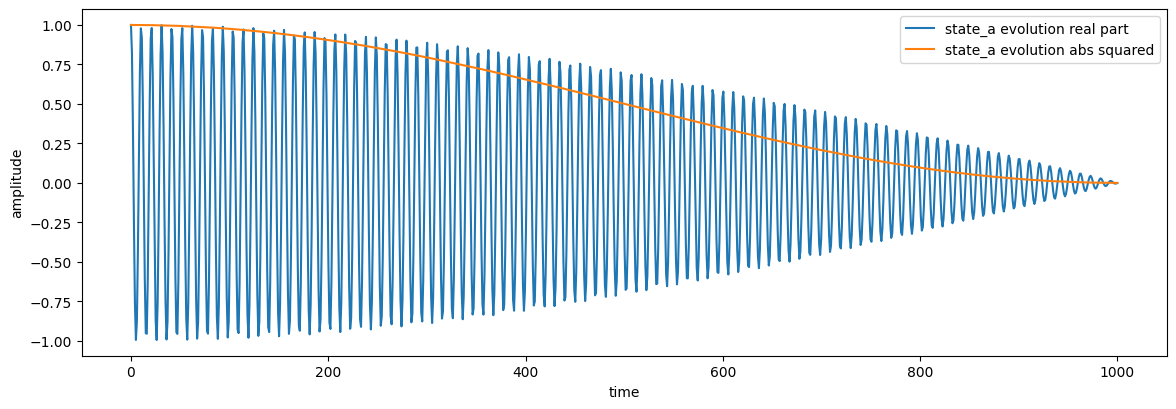

In [2]:
result_cos = mesolve(lh, psi0, tlist, e_ops=[])
result_cos_b = mesolve(lh, b, tlist,)
result_cos_c = mesolve(lh, b, tlist,)

psi_a_cos = [result_cos.states[i].overlap(Qobj(s.E_states[s.state_a])) for i in range(Nt)]

def plot_a_evolution(psi_a,):
    _, ax = plt.subplots(1, 1, figsize=(14, 4.5))
    ax.plot(tlist, np.real(psi_a), label='state_a evolution real part')
    ax.plot(tlist, np.abs(psi_a)**2, label='state_a evolution abs squared')
    ax.plot()
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel('amplitude')
    plt.show()
plot_a_evolution(psi_a_cos)

This plot shows, that fast oscillations will determine the phase completely and thus they have to be accounted for when choosing the gate parameters for iswap. The next step is to see, whether fast those fast oscillations can be predicted by Floquet theory. 

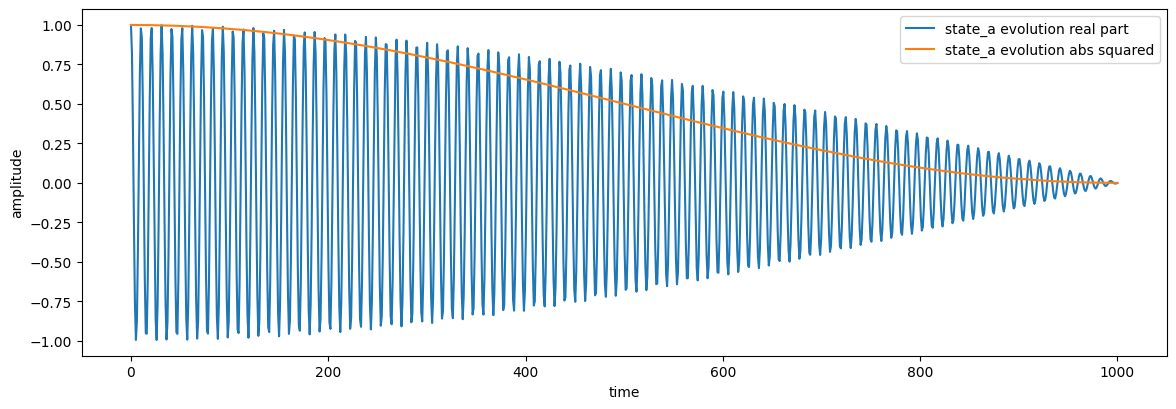

In [3]:
rH = 3
rW = 1
psi_floq, _ = Psi_t_FloquetPerturb(rH, rW, cos_wd, cos_amp, s.resonances, s.E_array, s.V1_dressed_array, psi0_dressed, tlist)
psi_a_floq = psi_floq[s.state_a, :]
plot_a_evolution(psi_a_floq)

The plot shows matching dynamics, thus floquet theory can predict the phase correctly for a cosine drive. Now let's use the precomputed pulse shape to implement a Gauss DRAG pulse and try to predict those fast oscillations. 

To keep computation times low, for the beginning a long gate time of 1 \mu s is used.

In [4]:
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
heff_file = coeff_dir / f"precomputed_heff_modulated{tg}_{Nt}.pkl"
with open(heff_file, 'rb') as f:
    heff_data = pickle.load(f)
print(f"heff_modulated loaded from {heff_file}")
freq = heff_data['frequency']
amp_real = heff_data['amplitude_real']
amp_imag = heff_data['amplitude_imag']

def drive_signal_interp(t, fc, arc, aic):
    if t <= tlist[0]:
        return [freq[0],0]
    if t >= tlist[-1]:
        return [freq[-1],0]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    ar = (1 - alpha) * arc[idx] + alpha * arc[idx + 1]
    ai = (1 - alpha) * aic[idx] + alpha * aic[idx + 1]
    wd = (1 - alpha) * fc[idx] + alpha * fc[idx + 1]
    return [wd, ar + 1j*ai]

heff_modulated loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated1000_1000.pkl


Now, just like with the cosine drive, the time evolution is computed with mesolve and with floquet theory for comparison. 

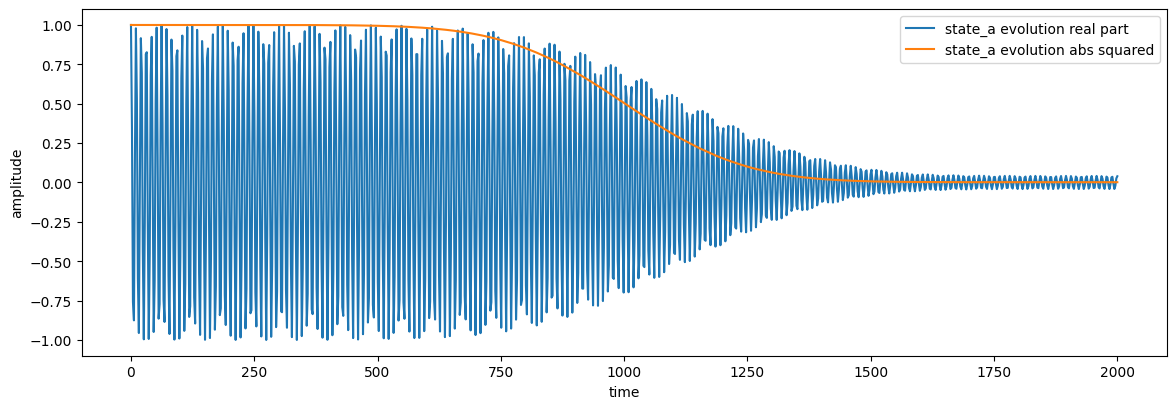

739it [01:02, 11.77it/s]


KeyboardInterrupt: 

In [11]:
# direct simulation
def signal_1000(t, args=None):
    s = drive_signal_interp(t, freq, amp_real, amp_imag)
    return np.real(s[1]) * np.cos(s[0]*t) + np.imag(s[1]) * np.sin(s[0]*t)
signal_1000_floq = lambda t: drive_signal_interp(t, freq, amp_real, amp_imag)

# tg_1000 = find_optimal_time_near_tg(rH, rW, 1000, signal_1000_floq, s.state_a, s.state_b, s.state_c, s.E_array, s.V1_dressed_array)
# print("tg 1000: ", tg_1000[0], " fid: ", tg_1000[1])

result = mesolve([s.H0, [s.V1, signal_1000]], psi0, tlist, e_ops=[])
result_b = mesolve([s.H0, [s.V1, signal_1000]], b, tlist, e_ops=[])
result_c = mesolve([s.H0, [s.V1, signal_1000]], c, tlist, e_ops=[])
psi_a = [result.states[i].overlap(Qobj(s.E_states[s.state_a])) for i in range(Nt)]
plot_a_evolution(psi_a)

# floquet theory
rH = 3
rW = 1
psi_floq, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, signal_1000_floq,
                                            s.resonances, s.E_array, s.V1_dressed_array, psi0_dressed, tlist, num = True)
psi_floq_b, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, signal_1000_floq,
                                            s.resonances, s.E_array, s.V1_dressed_array, b_dressed, tlist, num = True)
psi_floq_c, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, signal_1000_floq,
                                            s.resonances, s.E_array, s.V1_dressed_array, c_dressed, tlist, num = True)
psi_a_floq = psi_floq[s.state_a, :]
plot_a_evolution(psi_a_floq)

In [6]:
def compute_unitary(ra, rb, rc):
    U = np.zeros((3, 3), dtype=complex)
    U[0, 0] = ra[s.state_a]  # Project onto state a
    U[1, 0] = ra[s.state_b]  # Project onto state b
    U[2, 0] = ra[s.state_c]  # Project onto state c
    
    U[0, 1] = rb[s.state_a]  # Project onto state a
    U[1, 1] = rb[s.state_b]  # Project onto state b
    U[2, 1] = rb[s.state_c]  # Project onto state c

    U[0, 2] = rc[s.state_a]  # Project onto state a
    U[1, 2] = rc[s.state_b]  # Project onto state b
    U[2, 2] = rc[s.state_c]  # Project onto state c
    return U

# compute the unitary evolutions at gate time
U_1000 = compute_unitary(result.states[-1].full()[:,0], result_b.states[-1].full()[:,0], result_c.states[-1].full()[:,0])
U_1000_floq = compute_unitary(psi_floq[:,-1], psi_floq_b[:,-1], psi_floq_c[:,-1])

The plot shows that the prediction of fast oscillation is insufficient at rH=3 rW=2 as the end phase differs between the two simulations. Also apparently the floquet prediction doesn't capture the rest amplitude with which the wave function oscillates around the 800ns mark. 

These false predictions are believed to be caused by a too low order of prediction (rH). To verify this thesis the same siulation is repeated but this time with a gate time of 2 microseconds. 

heff_modulated loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated2000_1000.pkl


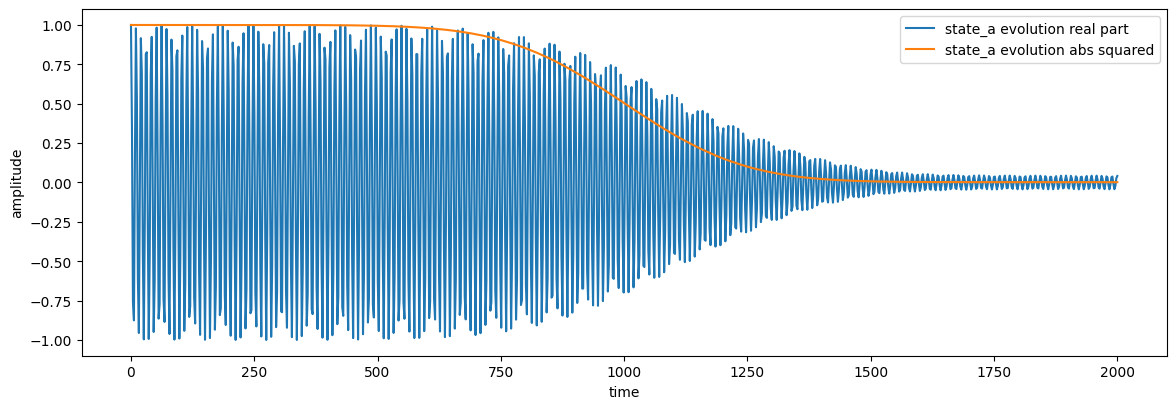

1000it [01:23, 12.04it/s]
1000it [01:23, 11.99it/s]
1000it [01:24, 11.88it/s]


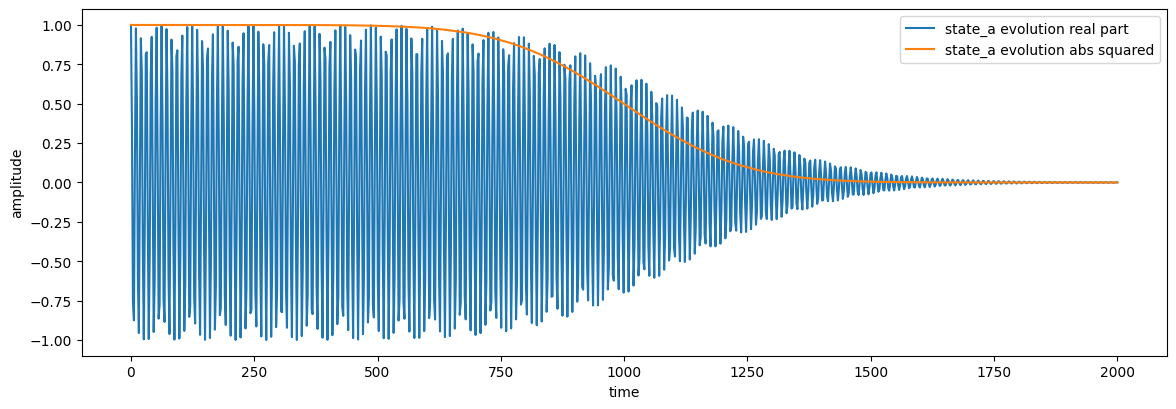

In [7]:
tg = 2000
Nt = 1000
tlist = np.linspace(0, tg, Nt)
cos_amp, cos_wd = compute_cos_params(s, tg)

heff_file = coeff_dir / f"precomputed_heff_modulated{tg}_{Nt}.pkl"
with open(heff_file, 'rb') as f:
    heff_data = pickle.load(f)
print(f"heff_modulated loaded from {heff_file}")
freq = heff_data['frequency']
amp_real = heff_data['amplitude_real']
amp_imag = heff_data['amplitude_imag']

# Gaus DRAG direct simulation
def signal_2000(t, args=None):
    s = drive_signal_interp(t, freq, amp_real, amp_imag)
    return s[1] * np.cos(s[0]*t) 
signal_2000_floq = lambda t: drive_signal_interp(t, freq, amp_real, amp_imag)

result = mesolve([s.H0, [s.V1, signal_2000]], psi0, tlist, e_ops=[])
result_b = mesolve([s.H0, [s.V1, signal_2000]], b, tlist, e_ops=[])
result_c = mesolve([s.H0, [s.V1, signal_2000]], c, tlist, e_ops=[])

psi_a = [result.states[i].overlap(Qobj(s.E_states[s.state_a])) for i in range(Nt)]
plot_a_evolution(psi_a)

# Gauss DRAG floquet prediction
rH = 3
rW = 1
psi_floq, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, signal_2000_floq,
                                            s.resonances, s.E_array, s.V1_dressed_array, psi0_dressed, tlist, num = True)
psi_floq_b, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, signal_2000_floq,
                                            s.resonances, s.E_array, s.V1_dressed_array, b_dressed, tlist, num = True)
psi_floq_c, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, signal_2000_floq,
                                            s.resonances, s.E_array, s.V1_dressed_array, c_dressed, tlist, num = True)
psi_a_floq = psi_floq[s.state_a, :]
plot_a_evolution(psi_a_floq)

In [8]:
# again, determine the unitary evolutions at gate time
U_2000 = compute_unitary(result.states[-1].full()[:,0], result_b.states[-1].full()[:,0], result_c.states[-1].full()[:,0])
U_2000_floq = compute_unitary(psi_floq[:,-1], psi_floq_b[:,-1], psi_floq_c[:,-1])

Apparently, the deviation is smaller in total, however the amplitude is too small too tell the applicability of oscillation prediction. 

To better quantify, let's compare the process fidelity for all 4 measurements. 

In [9]:
# Define ideal iSWAP gate for subsystem {i, f, l}
# iSWAP: |i⟩→i|f⟩, |f⟩→i|i⟩, |l⟩→|l⟩ (spectator)
U_ideal = np.array([[0, 1j, 0],
                    [1j, 0, 0],
                    [0, 0, 1]], dtype=complex)

# from the unitary evolutions, the process fidelity can be obtained
# Compute gate fidelity at each time: F = |Tr(U_ideal† U(t))|² / 3^2
fid_1000 = np.abs(np.trace(U_ideal.conj().T @ U_1000))**2 / 3**2
fid_1000_floq = np.abs(np.trace(U_ideal.conj().T @ U_1000))**2 / 3**2
fid_2000 = np.abs(np.trace(U_ideal.conj().T @ U_2000))**2 / 3**2
fid_2000_floq = np.abs(np.trace(U_ideal.conj().T @ U_2000_floq))**2 / 3**2

print(f"for 1 micro-s floquet theory: {fid_1000_floq:.2e} versus direct simulation {fid_1000:.2e}")
print(f"for 2 micro-s floquet theory: {fid_2000_floq:.2e} versus direct simulation {fid_2000:.2e}")

# display the matrices for visual comparison
display(Qobj(U_1000))
display(Qobj(U_1000_floq))
display(Qobj(U_2000))
display(Qobj(U_2000_floq))
display(Qobj(U_ideal))

print("cos for comparison")
U_cos = compute_unitary(result_cos.states[-1].full()[:,-1], result_cos_b.states[-1].full()[:,-1], result_cos_c.states[-1].full()[:,-1])
fid_cos = np.abs(np.trace(U_ideal.conj().T @ U_cos))**2 / 3**2
display(Qobj(U_cos))
fid_cos

for 1 micro-s floquet theory: 1.07e-01 versus direct simulation 1.07e-01
for 2 micro-s floquet theory: 2.62e-01 versus direct simulation 1.04e-01


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.07809501+0.04126053j -0.07809501+0.04126053j -0.07809501+0.04126053j]
 [-0.37017227-0.89712359j -0.37017227-0.89712359j -0.37017227-0.89712359j]
 [-0.09206661-0.20289406j -0.09206661-0.20289406j -0.09206661-0.20289406j]]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-5.65542590e-03+5.24863467e-03j  6.74150645e-01+7.38553570e-01j
   2.53516080e-06+9.55472899e-06j]
 [ 8.18314409e-01-5.74719058e-01j  4.38213713e-03+6.35050242e-03j
  -3.67712205e-06+8.67798577e-06j]
 [-2.20775586e-07+9.35606268e-06j -8.44644953e-06-5.25560554e-06j
   5.05574322e-01+8.62783058e-01j]]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.02977304+0.0433624j  0.02977304+0.0433624j  0.02977304+0.0433624j ]
 [0.19078318-0.95464924j 0.19078318-0.95464924j 0.19078318-0.95464924j]
 [0.04652907-0.21593948j 0.04652907-0.21593948j 0.04652907-0.21593948j]]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.48368577e-04-2.06139385e-03j -9.98633421e-01-5.22208641e-02j
  -4.73644270e-07-8.13809530e-06j]
 [ 3.75377418e-01+9.26869744e-01j -1.90001249e-03+8.13210105e-04j
   4.78850141e-06+6.75082727e-06j]
 [-6.73009214e-06+4.84630752e-06j  5.52034218e-06+5.97505933e-06j
   6.55442526e-01-7.55245056e-01j]]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.+0.j 0.+1.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]]

cos for comparison


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.005055  +0.059087j   -0.005055  +0.059087j   -0.005055  +0.059087j  ]
 [ 0.08218456-0.97169436j  0.08218456-0.97169436j  0.08218456-0.97169436j]
 [ 0.00344823-0.21178141j  0.00344823-0.21178141j  0.00344823-0.21178141j]]

np.float64(0.10111553943963239)

This shows, for gate times in the microsecond area and for low order rH=3/rw=1, fast oscillations can not be predicted precisely and thus the coparison of process fidelities gives no usefull insight other than indicating the failure of prediction. 

To get a more comparable result, let's use the floquet prediction to find a time ~tg which is is smaller than tg and locally maximizes the fidelity. 

In [10]:
# optimal time for 1000:
tg_1000 = find_optimal_time_near_tg(rH, rW, 1000, signal_1000, s.state_a, s.state_b, s.state_c, s.E_array, s.V1_dressed_array)

TypeError: cannot unpack non-iterable numpy.complex128 object